# Premium Prediction for Older Customers (>25) - Segmented Model

## 1. Introduction & Context
This notebook is part of a **model segmentation** strategy to improve our premium prediction accuracy.

### Why does this notebook exist?
- The initial model built in `ml_premium_prediction.ipynb` had a significant average prediction error, especially for younger customers.
- To fix this, we decided to split the data by age and build two separate, specialized models:
    1. A model for **younger customers (< 25)** using new `genetic_risk` data.
    2. A model for **older customers (>= 25)**, which is the focus of this notebook.

### How is this different?
- **Dataset:** This notebook uses `premiums_rest.xlsx`, which contains only customers aged 25 and older.
- **`genetic_risk` Feature:** Since genetic risk data was not available for this older group, we are adding a `genetic_risk` column and setting its value to `0`. This ensures the feature structure (schema) is identical to the model for the younger group, which is critical for streamlining the final prediction pipeline.

Our goal is to build a more accurate model for this specific age segment.

In [74]:
# Import necessary libraries for data manipulation, visualization, and modeling
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from joblib import dump
import numpy as np

## 2. Data Loading & Initial Setup
Here, we load the dataset for customers aged 25 and older and add the `genetic_risk` column to align our feature set with the model for the younger segment.

In [75]:
# Load the pre-split dataset containing only customers aged > 25
df = pd.read_excel('datasets/premiums_rest.xlsx')
# Add the 'genetical_risk' column and set it to 0 for all rows.
# This is because this data is unavailable for this age group, but we need feature consistency.
df['genetical_risk'] = 0
# Display the first few rows to confirm
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0


In [76]:
# Check the shape of the dataset to see how many customers are in this segment
df.shape

(29904, 14)

## 3. Data Cleaning & Preprocessing
This section covers the standard data cleaning steps: standardizing column names, handling missing values and duplicates, and correcting invalid data entries. This process is identical to the one in the main notebook.

In [77]:
# Standardize column names to lowercase with underscores for easier access
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [78]:
# Verify the column name changes
df.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0


In [79]:
# Check for any missing (null) values in the dataset
print(df.isna().sum())

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64


In [80]:
# Drop rows with any missing values to ensure data quality
df.dropna(inplace=True)
# Confirm that there are no more missing values
print(df.isna().sum())

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64


In [81]:
# Check for and count any duplicate rows
df.duplicated().sum()
# Remove duplicate rows from the dataset
# df.drop_duplicates(inplace=True)
df.duplicated().count()


np.int64(29886)

In [82]:
df.drop_duplicates(inplace=True)


In [83]:
df.duplicated().count()

np.int64(29886)

In [84]:
# Get a statistical summary of the numerical columns
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000,29886.000,29886.000,29886.000,29886.000
mean,43.396,2.380,23.364,20892.304,0.000
std,13.413,1.431,24.740,6936.813,0.000
min,26.000,-3.000,1.000,3625.000,0.000
25%,34.000,1.000,7.000,15697.250,0.000
50%,42.000,3.000,17.000,20489.000,0.000
75%,52.000,3.000,32.000,26360.000,0.000
max,356.000,5.000,930.000,43471.000,0.000


In [85]:
# Identify any records with a negative number of dependants, which is a data error
df[df['number_of_dependants']<0].shape ,df[df['number_of_dependants']<0]['number_of_dependants'].unique()

((50, 14), array([-1, -3]))

In [86]:
# Correct the error by taking the absolute value of the 'number_of_dependants'
df['number_of_dependants'] = df['number_of_dependants'].abs()
# Verify the correction by checking the description again
df.number_of_dependants.describe()

count   29886.000
mean        2.386
std         1.421
min         0.000
25%         1.000
50%         3.000
75%         3.000
max         5.000
Name: number_of_dependants, dtype: float64

In [87]:
# Get a concise summary of the dataframe, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29886 entries, 0 to 29903
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    29886 non-null  int64 
 1   gender                 29886 non-null  object
 2   region                 29886 non-null  object
 3   marital_status         29886 non-null  object
 4   number_of_dependants   29886 non-null  int64 
 5   bmi_category           29886 non-null  object
 6   smoking_status         29886 non-null  object
 7   employment_status      29886 non-null  object
 8   income_level           29886 non-null  object
 9   income_lakhs           29886 non-null  int64 
 10  medical_history        29886 non-null  object
 11  insurance_plan         29886 non-null  object
 12  annual_premium_amount  29886 non-null  int64 
 13  genetical_risk         29886 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 3.4+ MB


## 4. Outlier Detection and Treatment
Here, we'll look for and handle outliers in our numerical columns, particularly for `age` and `income`, to prevent them from skewing our model's performance.

In [88]:
# Select all columns with integer data types to check for outliers
numeric_cols = df.select_dtypes('int64').columns
print(numeric_cols)

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')


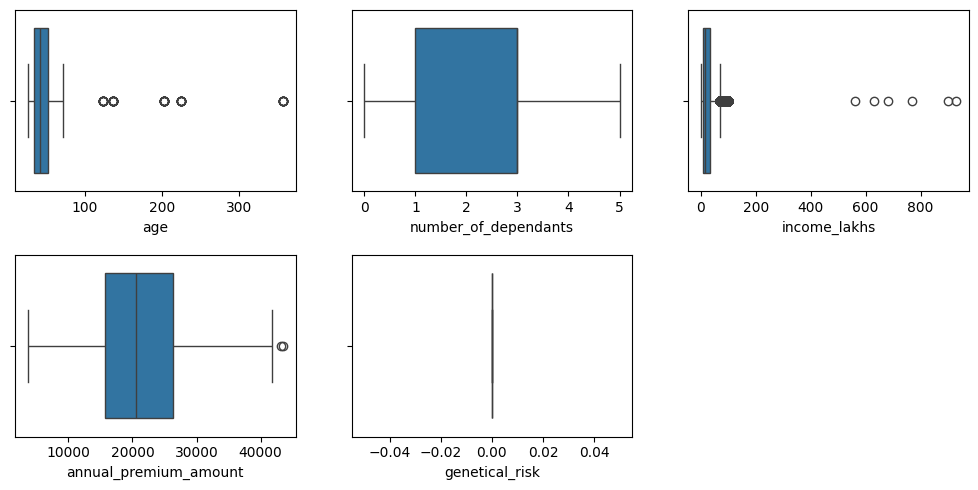

In [89]:
# Create boxplots for each numerical column to visually identify outliers
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

for i, columns in enumerate(numeric_cols):
    ax = axs.flatten()[i]
    sns.boxplot(x=df[columns], ax=ax)
plt.tight_layout()
# Hide the last empty subplot for a cleaner look
axs.flatten()[-1].set_visible(False)
plt.show()

**Insight:** The boxplot for `genetical_risk` shows a single line at 0, which is expected since we manually set this value for all customers in this segment.

In [90]:
# Check for any ages over 100, which are likely data entry errors
df[df.age>100].shape, df[df.age>100].age.unique()

((58, 14), array([224, 124, 136, 203, 356]))

In [91]:
# Filter out records where age is greater than 100
df1 = df[df.age <= 100]
# Print the new shape and age description to confirm the change
print(df1.shape)
print(df1.age.describe())
df1.head()

(29828, 14)
count   29828.000
mean       43.095
std        11.042
min        26.000
25%        34.000
50%        42.000
75%        52.000
max        72.000
Name: age, dtype: float64


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0


In [92]:
# Define a function to calculate Interquartile Range (IQR) bounds for outlier detection
def gte_IQR_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    upper =Q3 + 1.5*IQR
    lower =Q1 - 1.5*IQR
    return upper,lower

# Calculate the IQR bounds for the 'income_lakhs' column
u, l = gte_IQR_bounds(df1.income_lakhs)
print('upper',u)
print('lower',l)

upper 69.5
lower -30.5


In [93]:
# Check how many records have an income above the calculated upper bound
df1[df1.income_lakhs > u].shape

(2090, 14)

In [94]:
# As an alternative to IQR, we use the 99.9th percentile to cap extreme high incomes
quantity_threshold_income = df1.income_lakhs.quantile(0.999)
quantity_threshold_income

np.float64(100.0)

In [95]:
# Check how many records fall above this 99.9th percentile threshold
df1[df1.income_lakhs > quantity_threshold_income].shape

(6, 14)

In [96]:
# Create the final cleaned dataframe by removing the extreme income outliers
df2 = df1[df1.income_lakhs <= quantity_threshold_income].copy()
print(df2.shape)
df2.head()

(29822, 14)


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0


## 5. Exploratory Data Analysis (EDA)
Now we'll explore the cleaned data to understand distributions and relationships between variables.

### 5.1 Univariate Analysis: Numerical Columns
Let's look at the distribution of each numerical feature.

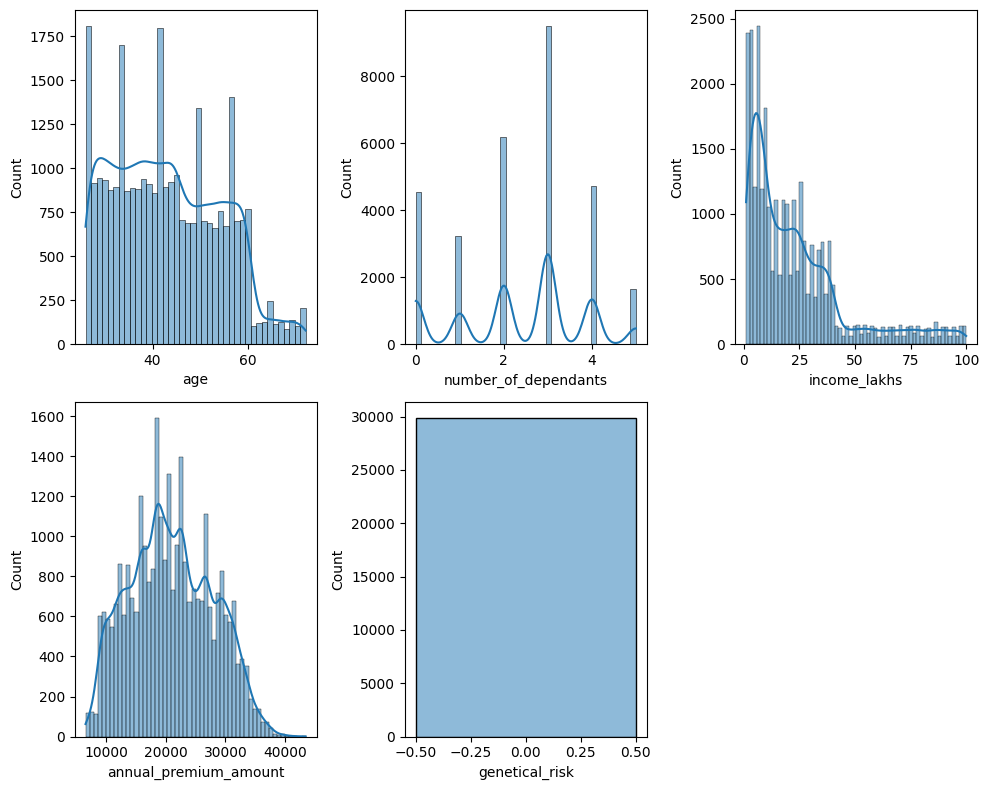

In [97]:
# Plot histograms for each numerical column to see their distributions
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))

for i, columns in enumerate(numeric_cols):
    ax = axs.flatten()[i]
    sns.histplot(df2[columns], ax=ax, kde=True)
# Hide the last empty subplot
axs.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [98]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0


### 5.2 Bivariate Analysis: Numeric Columns vs. Premium
Here we check how our numeric features relate to the `annual_premium_amount`.

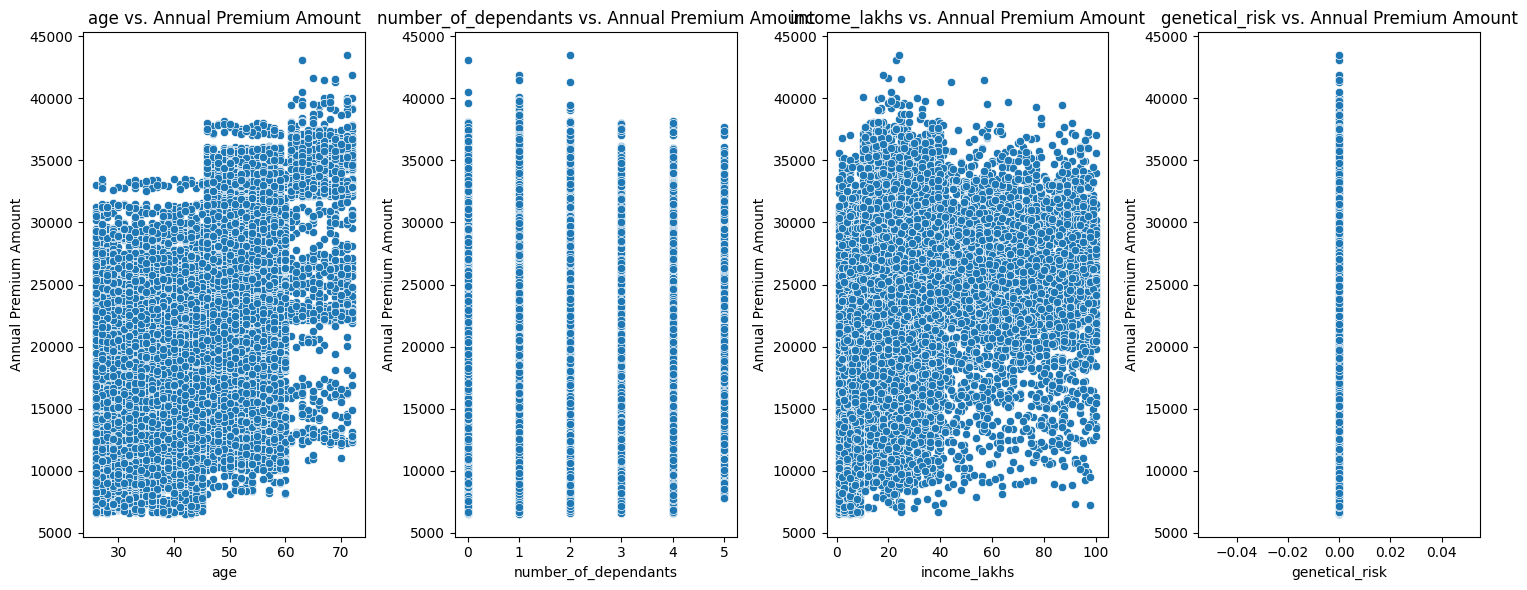

In [99]:
# List the numeric features we want to plot against the premium amount
numeric_features = ['age', 'number_of_dependants', 'income_lakhs', 'genetical_risk']
# Create scatter plots for each feature against the annual premium
fig, axs = plt.subplots(1, len(numeric_features), figsize=(15, 6))

for i, col in enumerate(numeric_features):
    ax = axs[i]
    sns.scatterplot(x=df2[col], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{col} vs. Annual Premium Amount')
    ax.set_xlabel(col)
    ax.set_ylabel('Annual Premium Amount')
plt.tight_layout()
plt.show()

**Insight:** The scatter plot for `genetical_risk` vs. premium is a vertical line at x=0. This confirms the feature has no predictive power for this segment but is kept for schema consistency with the younger (<25) customer model.

### 5.3 Categorical Columns Analysis
Let's inspect and clean our categorical (text-based) features.

In [100]:
# Identify all categorical columns in the dataframe
cat_cols = df2.select_dtypes('object').columns
cat_cols

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [101]:
# Print the unique values for each categorical column to check for inconsistencies
for col in cat_cols:
    print(f"{col}: {df2[col].unique()}")

gender: ['Male' 'Female']
region: ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status: ['Unmarried' 'Married']
bmi_category: ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status: ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status: ['Salaried' 'Self-Employed' 'Freelancer']
income_level: ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history: ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan: ['Bronze' 'Silver' 'Gold']


In [102]:
# Standardize the values in the 'smoking_status' column for consistency
df2['smoking_status'] = df2['smoking_status'].replace({
    'Smoking=0':'No Smoking',
    'Does Not Smoke':'No Smoking',
    'Not Smoking':'No Smoking'
})
# Verify the changes
df2['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [103]:
# Re-check unique values to ensure all categories are clean
for col in cat_cols:
    print(f"{col}: {df2[col].unique()}")

gender: ['Male' 'Female']
region: ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status: ['Unmarried' 'Married']
bmi_category: ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status: ['No Smoking' 'Regular' 'Occasional']
employment_status: ['Salaried' 'Self-Employed' 'Freelancer']
income_level: ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history: ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan: ['Bronze' 'Silver' 'Gold']


#### Univariate Analysis: Categorical Features
Let's visualize the distribution of policyholders across different categories.

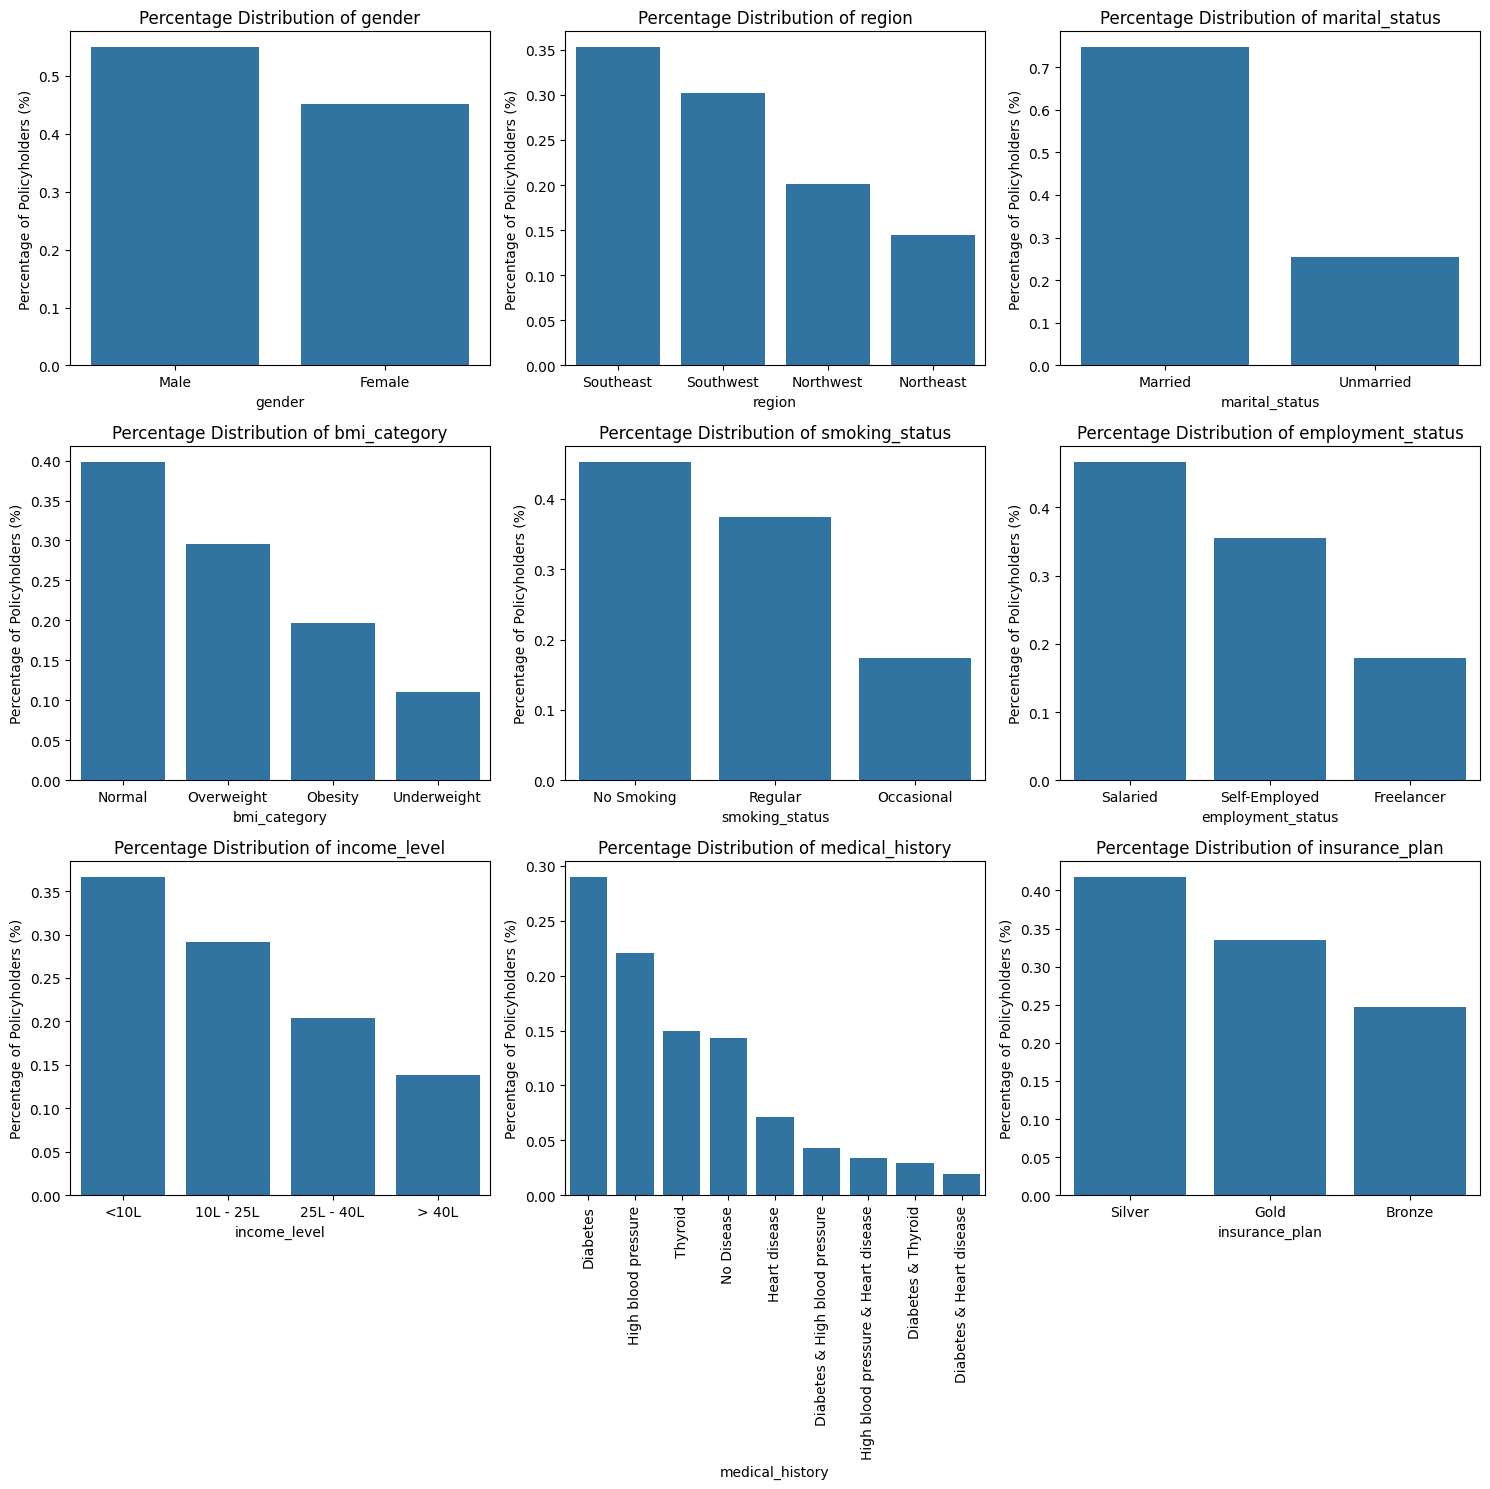

In [104]:
# Create bar plots showing the percentage distribution for each categorical feature
fig, axs = plt.subplots(3, 3, figsize = (15, 15))

for i, col in enumerate(cat_cols):
    ax = axs.flatten()[i]
    pct_count = df2[col].value_counts(normalize=True)

    sns.barplot(x=pct_count.index, y=pct_count.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {col}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(col)

    # Rotate x-axis labels if they are too long or numerous to prevent overlap
    if len(pct_count.index) > 4 or any(len(str(x)) > 20 for x in pct_count.index):
        ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

#### Bivariate Analysis: Income Level vs. Insurance Plan
Let's see if there's a relationship between a customer's income and their chosen insurance plan.

In [105]:
# Create a cross-tabulation to see the relationship between income level and insurance plan
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,799,3554,4354
25L - 40L,301,2631,3142
<10L,6054,527,4341
> 40L,214,3287,618


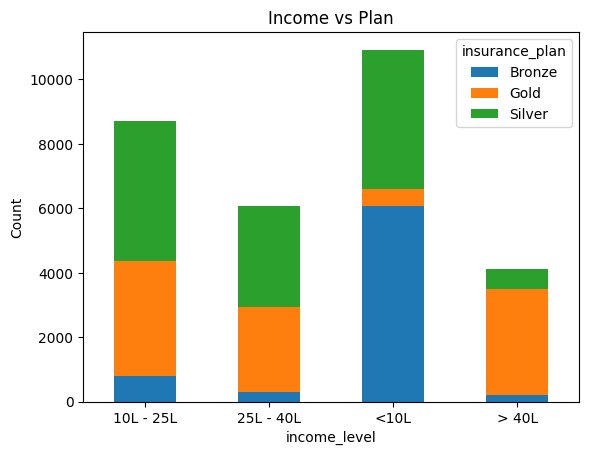

In [106]:
# Visualize the crosstab with a stacked bar chart
crosstab.plot(kind="bar", rot=0, stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

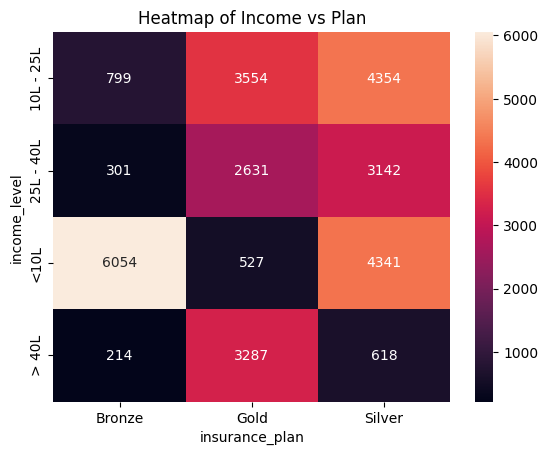

In [107]:
# Visualize the same relationship using a heatmap for another perspective
sns.heatmap(data=crosstab, annot=True, fmt="g")
plt.title('Heatmap of Income vs Plan')
plt.show()

## 6. Feature Engineering

In this section, we'll create new, model-friendly features from our existing data. This includes creating a numerical risk score and converting all text-based categories into numbers.

In [108]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0


### 6.1 Calculating a Numerical Risk Score
We will convert the `medical_history` text into a numerical `normalized_risk_score`.

In [109]:
# Check the unique values in the medical history column
df.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [110]:
# Define a risk score for each disease. Higher scores mean higher risk.
risk_score = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

# Split 'medical_history' into two separate disease columns
df2[['disease1', 'disease2']] = df2.medical_history.str.split(' & ', expand=True).apply(lambda x: x.str.lower())
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,None


In [111]:
# Fill any empty second disease slots with 'none'
df2[['disease1', 'disease2']] = df2[['disease1', 'disease2']].fillna('none')
# Initialize the total risk score column
df2['total_risk_score'] = 0

# Map the diseases in each column to their scores and sum them up
for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_score)

# Normalize the risk score to a 0-1 scale using MinMaxScaler
scale = MinMaxScaler()
df2['normalized_risk_score'] = scale.fit_transform(df2[['total_risk_score']])
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,none,6,0.429
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,none,6,0.429
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,high blood pressure,none,6,0.429
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,no disease,none,0,0.000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,diabetes,none,6,0.429


In [112]:
# Check a few records with two diseases to ensure the score was calculated correctly
df2[df2.disease2 != 'none'].head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
5,33,Male,Southeast,Married,3,Normal,Regular,Self-Employed,<10L,4,Diabetes & High blood pressure,Silver,20653,0,diabetes,high blood pressure,12,0.857
25,29,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,10L - 25L,11,High blood pressure & Heart disease,Gold,29249,0,high blood pressure,heart disease,14,1.000
27,26,Male,Northwest,Married,2,Obesity,Regular,Salaried,10L - 25L,21,Diabetes & Thyroid,Silver,24756,0,diabetes,thyroid,11,0.786
32,37,Female,Northeast,Married,3,Underweight,Occasional,Self-Employed,> 40L,84,Diabetes & High blood pressure,Gold,25477,0,diabetes,high blood pressure,12,0.857
39,34,Male,Northeast,Married,4,Underweight,No Smoking,Self-Employed,> 40L,97,Diabetes & Heart disease,Gold,27031,0,diabetes,heart disease,14,1.000


### 6.2 Encoding Text Columns
Machine learning models require numerical input, so we'll convert our categorical features into numbers.

In [113]:
# Check the unique values for the insurance plan
df2.insurance_plan.unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

In [114]:
# Map ordinal features (where order matters) to numbers
# For insurance_plan: Bronze (1) < Silver (2) < Gold (3)
df2['insurance_plan'] = df2['insurance_plan'].map({
    'Bronze':1,
    'Silver':2,
    'Gold': 3
})
# For income_level: Map income brackets to an ordered numerical scale
df2['income_level'] = df2['income_level'].map({
    '<10L':1,
    '10L - 25L':2,
    '25L - 40L':3,
    '> 40L':4
})

# Verify the unique values are now numeric
df2['insurance_plan'].unique(), df2['income_level'].unique()

(array([1, 2, 3]), array([1, 2, 4, 3]))

In [115]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,0,diabetes,none,6,0.429
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,0,diabetes,none,6,0.429


In [116]:
# One-hot encode nominal features (where order does not matter)
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
pd.set_option('display.max_columns', None)
# Use get_dummies to create binary columns for each category, dropping one to avoid multicollinearity
df3 = pd.get_dummies(data=df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(5)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,0,diabetes,none,6,0.429,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,0,diabetes,none,6,0.429,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,0,high blood pressure,none,6,0.429,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,0,no disease,none,0,0.000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,0,diabetes,none,6,0.429,1,0,0,0,0,1,0,0,1,0,0,1


### 6.3 Feature Selection
Finally, we drop the original raw text columns that we have now engineered into numerical features.

In [117]:
# Drop the original text and intermediate score columns, keeping only the final engineered features
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df4.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0,0.429,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0,0.429,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0,0.429,0,0,0,0,0,0,0,0,0,0,0,1


## 7. Final Feature Preparation
Before modeling, we'll check for multicollinearity and scale our features.

### 7.1 Multicollinearity Check (VIF)
We'll check if any of our features are highly correlated with each other.

In [118]:
# Display all column names in our final feature set
df4.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'genetical_risk',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

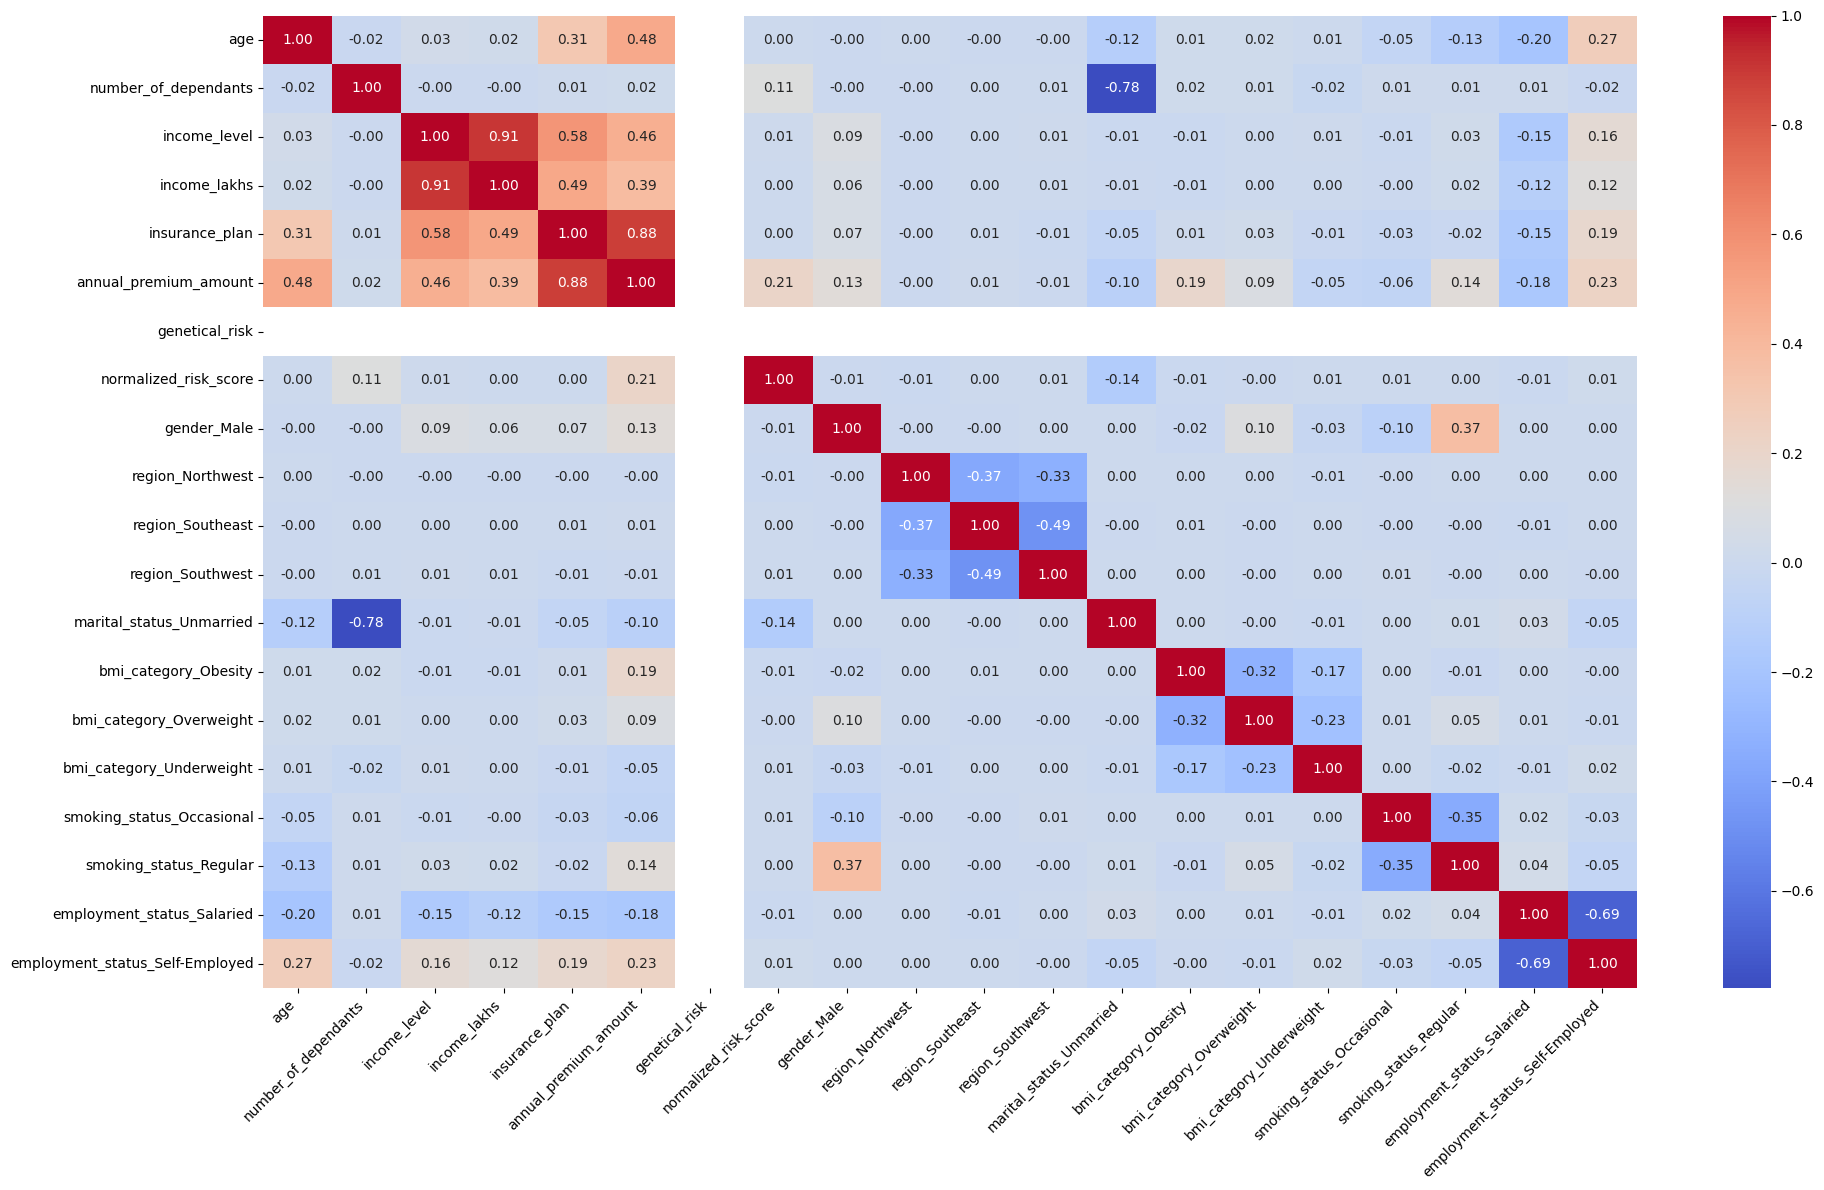

In [119]:
# Calculate and visualize the correlation matrix as a heatmap
cm = df4.corr()
plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [120]:
# Separate the data into features (X) and the target variable (y)
X = df4.drop('annual_premium_amount', axis=1)
y = df4['annual_premium_amount']

# Define the columns that need to be scaled and apply MinMaxScaler
# We include 'genetical_risk' here to ensure the scaler is fitted on the same features as the other model
cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan', 'genetical_risk']
X[cols_to_scale] = scale.fit_transform(X[cols_to_scale])

In [121]:
# Display the summary statistics for the scaled features
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000,29822.000
mean,0.372,0.478,0.371,0.225,0.544,0.000,0.426,0.549,0.201,0.353,0.302,0.253,0.197,0.295,0.110,0.173,0.375,0.466,0.354
std,0.240,0.284,0.351,0.227,0.379,0.000,0.240,0.498,0.401,0.478,0.459,0.435,0.398,0.456,0.313,0.378,0.484,0.499,0.478
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.174,0.200,0.000,0.061,0.500,0.000,0.357,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.348,0.600,0.333,0.162,0.500,0.000,0.429,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.565,0.600,0.667,0.313,1.000,0.000,0.429,1.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,0.000,1.000,1.000,1.000
max,1.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [122]:
# Import the Variance Inflation Factor (VIF) tool
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define a function to calculate VIF for each feature
def calculate_vif(data):
        vif_df = pd.DataFrame()
        vif_df['Column'] = data.columns
        vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
        return vif_df

In [123]:
# Calculate and display the VIF scores for our features
calculate_vif(X)

c:\Users\psjhi\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Column,VIF
0,age,3.922
1,number_of_dependants,6.279
2,income_level,13.891
3,income_lakhs,11.186
4,insurance_plan,5.271
5,genetical_risk,NaN
6,normalized_risk_score,3.811
7,gender_Male,2.599
8,region_Northwest,2.124
9,region_Southeast,2.981


**Insight on VIF:** Features such as `income_level` and `income_lakhs` have a VIF greater than 10, indicating high multicollinearity. This means these features are strongly correlated with other independent variables in the dataset, which can make the model's coefficients unstable and harder to interpret.

In [124]:
# Drop 'income_level' to reduce multicollinearity, as 'income_lakhs' provides similar, more precise information
X.drop('income_level', axis=1, inplace=True)
# Remove it from cols_to_scale as well for the final scaler export
# cols_to_scale.remove('income_level')

In [125]:
# Display VIF scores after dropping 'income_level'
calculate_vif(X)

c:\Users\psjhi\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Column,VIF
0,age,3.863
1,number_of_dependants,6.278
2,income_lakhs,2.678
3,insurance_plan,4.575
4,genetical_risk,NaN
5,normalized_risk_score,3.808
6,gender_Male,2.591
7,region_Northwest,2.123
8,region_Southeast,2.980
9,region_Southwest,2.709


## 8. Model Training & Evaluation

Now we'll train and evaluate several regression models to find the best one for predicting premiums for this customer segment.

In [126]:
# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Print the shapes of the splits to verify
print('X Train', X_train.shape)
print('Y Train', y_train.shape)
print('X Test', X_test.shape)
print('Y Test', y_test.shape)

X Train (20875, 18)
Y Train (20875,)
X Test (8947, 18)
Y Test (8947,)


### 8.1 Linear Regression
A simple baseline model to start with.

In [127]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model's performance using R-squared on both train and test sets
test_Score = model.score(X_test, y_test)
train_Score = model.score(X_train, y_train)

# Make predictions and calculate error metrics
pred_y = model.predict(X_test)
mse = mean_squared_error(y_test, pred_y)
rmse = np.sqrt(mse)

print("Test Score Of Linear Regression:",test_Score)
print("Train Score Of Linear Regression:",train_Score)
print("MSE:",mse)
print("RMSE:",rmse)

Test Score Of Linear Regression: 0.9546117251336063
Train Score Of Linear Regression: 0.9530815646744318
MSE: 2183801.881857191
RMSE: 1477.7692248308567


In [128]:
# Set pandas display option for better float formatting
pd.set_option('display.float_format', '{:.3f}'.format)
# Extract and view the coefficients (importance) of each feature
features_importance = model.coef_
coef_df = pd.DataFrame(data=features_importance, index=X_train.columns, columns=['Coefficients'])
coef_df.sort_values(by='Coefficients', ascending=True, inplace=True)
coef_df

,Coefficients
number_of_dependants,-1247.793
income_lakhs,-748.505
marital_status_Unmarried,-702.172
region_Northwest,-76.166
employment_status_Salaried,-73.460
region_Southwest,-53.338
region_Southeast,-25.083
genetical_risk,0.000
gender_Male,42.766
employment_status_Self-Employed,248.754


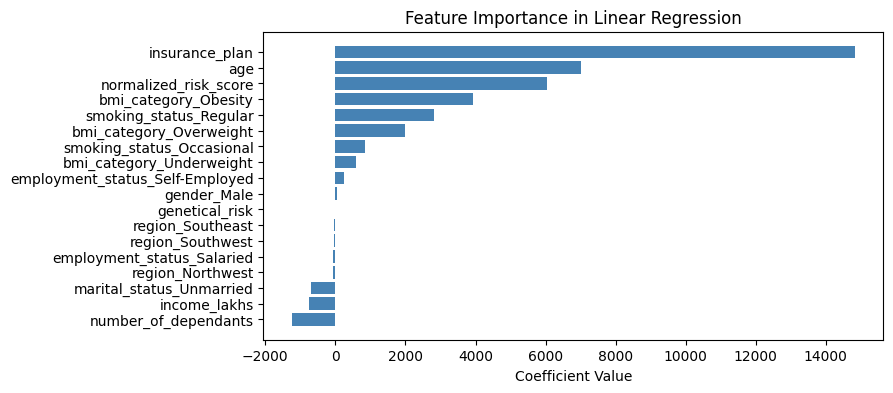

In [129]:
# Visualize the feature importance
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

### 8.2 Ridge Regression
A variation of Linear Regression that adds a penalty to prevent overfitting.

In [130]:
# Initialize and train the Ridge Regression model
model = Ridge(alpha=1)
model.fit(X_train, y_train)

# Evaluate the model's performance
test_Score = model.score(X_test, y_test)
train_Score = model.score(X_train, y_train)
pred_y = model.predict(X_test)
mse = mean_squared_error(y_test, pred_y)
rmse = np.sqrt(mse)

print("Test Score Of Ridge Regression:",test_Score)
print("Train Score Of Ridge Regression:",train_Score)
print("MSE:",mse)
print("RMSE:",rmse)

Test Score Of Ridge Regression: 0.954612316781273
Train Score Of Ridge Regression: 0.9530813964457598
MSE: 2183773.4154461706
RMSE: 1477.759593251274


### 8.3 XGBoost Regressor
A more powerful, tree-based model that can capture complex, non-linear patterns.

In [131]:
# Initialize and train a basic XGBoost Regressor model
model = XGBRegressor(n_estimators=20, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model's performance
test_Score = model.score(X_test, y_test)
train_Score = model.score(X_train, y_train)
pred_y = model.predict(X_test)
mse = mean_squared_error(y_test, pred_y)
rmse = np.sqrt(mse)

print("Test Score Of XGBoost Regression:",test_Score)
print("Train Score Of XGBoost Regression:",train_Score)
print("MSE:",mse)
print("RMSE:",rmse)

Test Score Of XGBoost Regression: 0.9950187802314758
Train Score Of XGBoost Regression: 0.995059072971344
MSE: 239665.8125
RMSE: 489.5567510513975


### 8.4 XGBoost Hyperparameter Tuning
We'll use `RandomizedSearchCV` to find the optimal settings for our XGBoost model to maximize its performance.

In [132]:
# Initialize the XGBoost model
model = XGBRegressor(random_state=42)
# Define a grid of hyperparameters to search through
pera_grid = {
    'n_estimators':[20, 40, 50],
    'learning_rate':[0.01, 0.1, 0.2],
    'max_depth':[3, 4, 5]
}

# Set up and run the randomized search with 3-fold cross-validation
rendom_search = RandomizedSearchCV(model, pera_grid, cv=3, n_iter=10, scoring='r2', n_jobs=1, random_state=42)
rendom_search.fit(X_train, y_train)
# Print the best R2 score found during the search
print(f"Best CV Score: {rendom_search.best_score_}")

Best CV Score: 0.9970021843910217


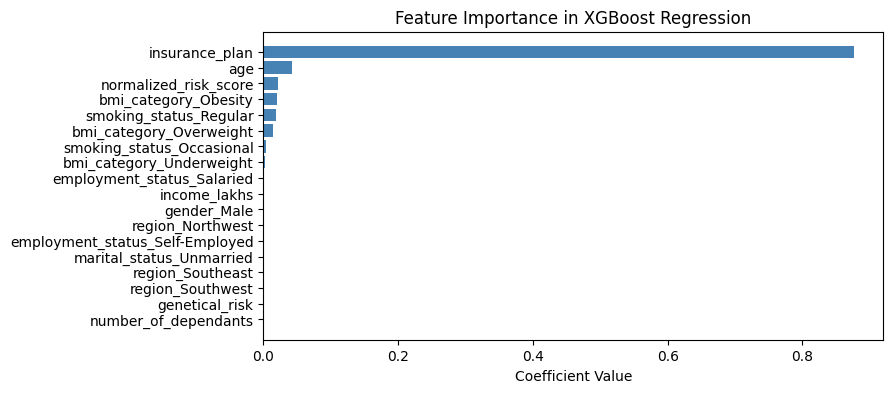

In [133]:
# Get the best performing model from the search
best_model = rendom_search.best_estimator_
# Extract and visualize its feature importances
features_importance = best_model.feature_importances_
coef_df = pd.DataFrame(data=features_importance, index=X_train.columns, columns=['Coefficients'])
coef_df.sort_values(by='Coefficients', ascending=True, inplace=True)
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost Regression')
plt.show()

**Modeling Insights:** The tuned XGBoost model provides the best performance, with a high R-squared value. The feature importance plot shows that `age`, `normalized_risk_score`, and `income_lakhs` are the most influential factors in determining the premium for this age group.

---
## 9. Error Analysis
Let's dive deeper into the predictions of our best model to understand where it's making mistakes.

In [134]:
# Make predictions on the test set using our best model
pred_y = best_model.predict(X_test)
# Calculate the raw and percentage difference between predicted and actual values
residuals = pred_y - y_test
residuals_ptc = ( residuals / y_test ) * 100

# Create a dataframe to analyze the results
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': pred_y,
    'diff': residuals,
    'diff_ptc': residuals_ptc
})
results_df.head()

,actual,predicted,diff,diff_ptc
5495,30838,31168.615,330.615,1.072
582,26306,26138.770,-167.230,-0.636
281,17983,17611.283,-371.717,-2.067
15443,19345,18925.240,-419.760,-2.170
24281,33317,33256.734,-60.266,-0.181


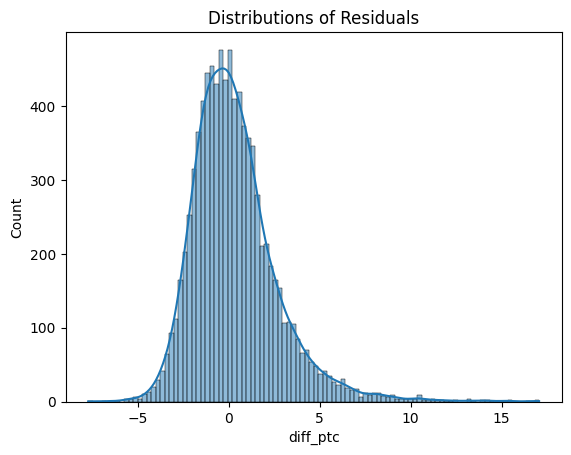

In [135]:
# Plot a histogram of the percentage errors to see their distribution
sns.histplot(results_df['diff_ptc'], bins=100, kde=True)
plt.title("Distributions of Residuals")
plt.show()

**Insight:** The error distribution is centered around zero, which is good. However, we can see some tails, indicating there are predictions with larger errors.

In [136]:
# Define a threshold for what we consider an "extreme" error (e.g., >6% difference)
extreme_error_threshold = 6
# Filter for predictions where the positive error is greater than the threshold
extreme_result_df = results_df[results_df.diff_ptc > extreme_error_threshold]
print("Shape:",extreme_result_df.shape)
extreme_result_df.head()

Shape: (228, 4)


,actual,predicted,diff,diff_ptc
17866,6909,7653.523,744.523,10.776
29124,8770,9442.622,672.622,7.670
22253,8676,9442.622,766.622,8.836
9243,9590,10262.917,672.917,7.017
252,7633,8430.018,797.018,10.442


In [137]:
# Calculate the percentage of test predictions that are considered extreme errors
extreme_errors_pct = extreme_result_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

2.5483402257740027

**Insight on Errors:** With our segmented model, the percentage of "extreme errors" is significantly lower than in our original, unified model. This confirms that the segmentation strategy is working and providing more accurate predictions for this group.

In [138]:
# Check how many predictions are off by a very large margin (e.g., >50%)
extreme_result_df[abs(extreme_result_df.diff_ptc) > 50].shape

(0, 4)

In [139]:
# Isolate the features of the records that resulted in extreme errors
extreme_error_df = X_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
17866,0.152,0.600,0.061,0.000,0.000,0.000,0,0,0,0,0,0,0,0,0,0,1,0
29124,0.283,0.000,0.020,0.000,0.000,0.429,0,0,0,0,1,0,0,0,0,0,0,1
22253,0.217,0.600,0.071,0.000,0.000,0.357,0,0,1,0,0,0,0,0,0,0,1,0
9243,0.413,0.000,0.010,0.000,0.000,0.357,0,1,0,0,1,0,0,0,1,0,1,0
252,0.065,0.600,0.020,0.000,0.000,0.000,1,0,1,0,0,0,0,0,1,0,0,0


In [140]:
# Check the number of columns for plotting
len(X_test.columns)

18

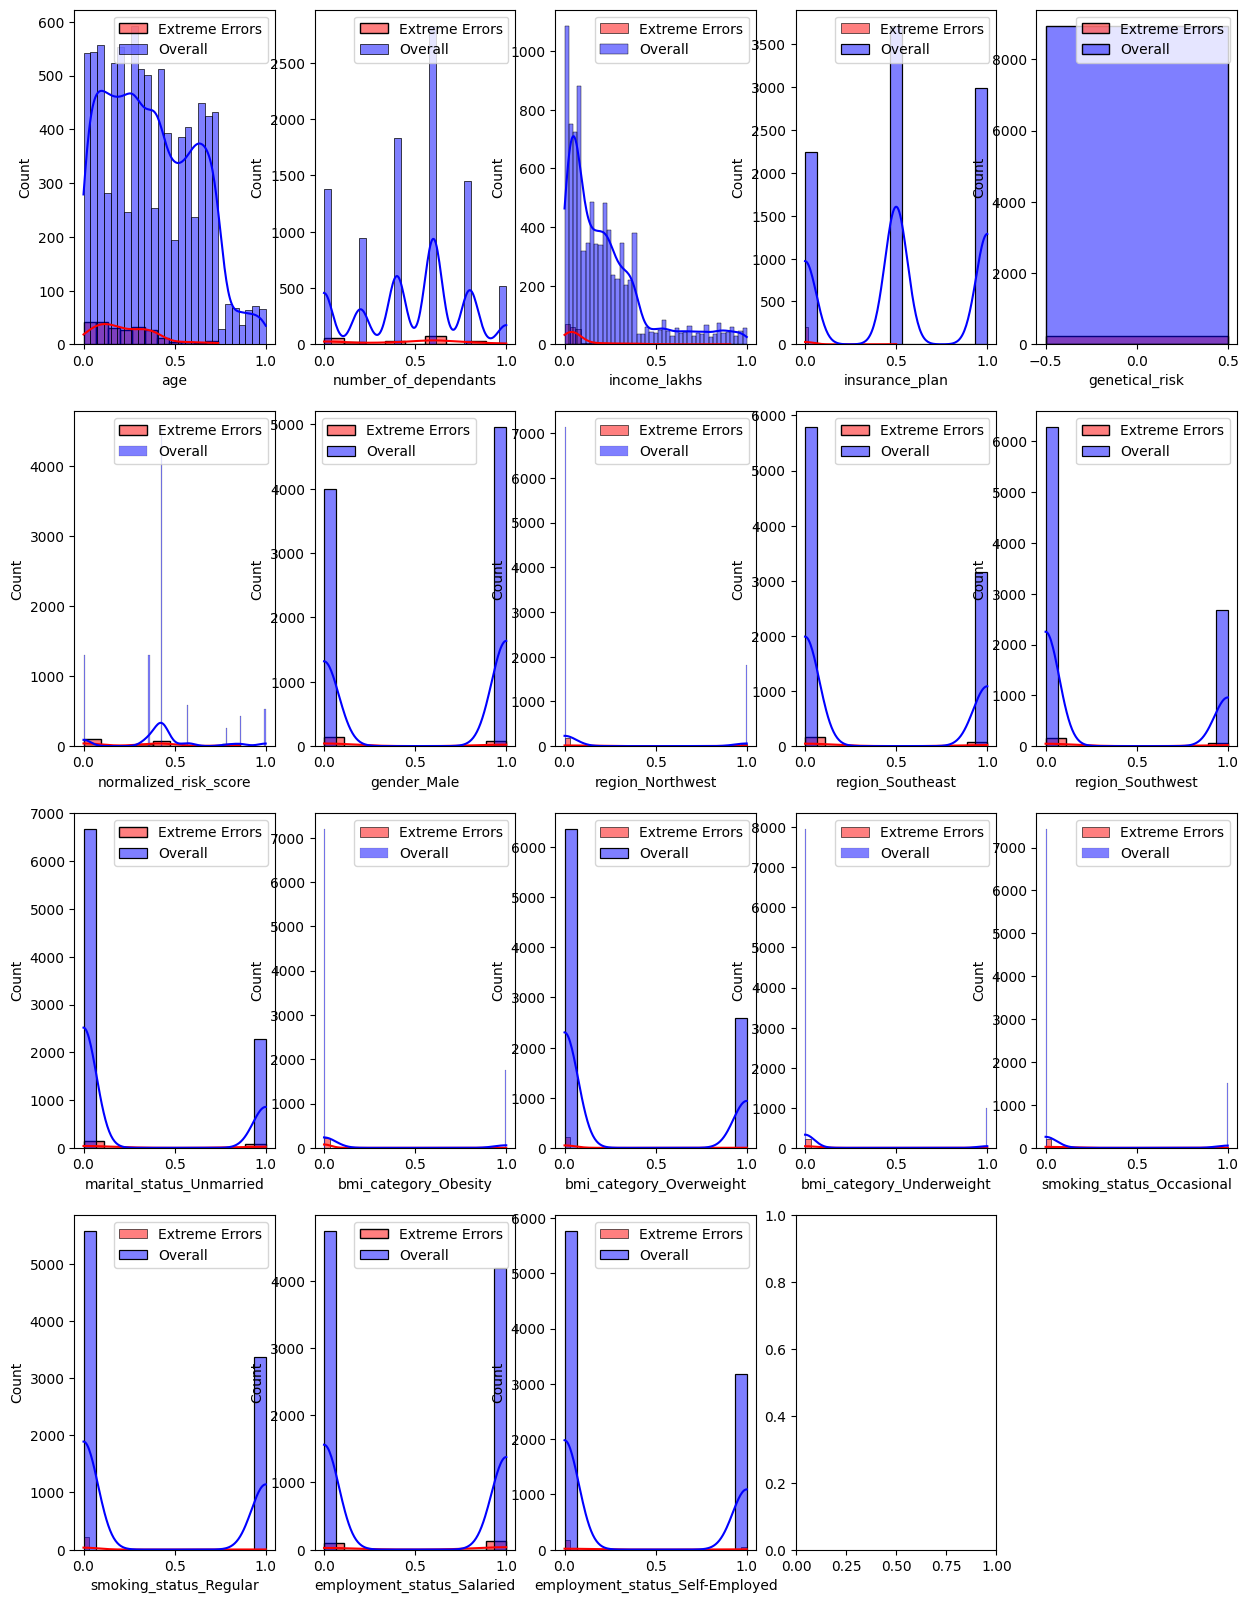

In [141]:
# Plot the distribution of features for extreme error cases (red) vs. the overall test set (blue)
# This helps us see if errors are concentrated in specific subgroups.
fig, axs = plt.subplots(4, 5, figsize=(15, 20))
for i, col in enumerate(X_test.columns):
    ax = axs.flatten()[i]
    sns.histplot(extreme_error_df[col], color='red', ax=ax, label='Extreme Errors', kde=True)
    sns.histplot(X_test[col], color='blue', ax=ax, label='Overall',kde=True)
    ax.legend()
axs.flatten()[-1].set_visible(False)
plt.show()

## 10. Exporting Model for Deployment
Finally, we save our trained model and the scaler object so they can be used in a live application.

In [142]:
# Display the best model object
best_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [143]:
# Use joblib to save the trained model to a file
dump(best_model, 'app/artifacts/model_rest.joblib')

# Create a dictionary to save both the scaler object and the list of columns it applies to
scaler_with_cols = {
    'scaler': scale,
    'cols_to_scale': cols_to_scale
}

# Save the scaler dictionary to a file
dump(scaler_with_cols, 'app/artifacts/scaler_rest.joblib')

['app/artifacts/scaler_rest.joblib']

---
## 11. Final Conclusions & Summary

1.  **Objective Achieved:** We successfully built a specialized prediction model for customers aged 25 and older. This **segmented approach** yielded a model that is significantly more accurate for this demographic compared to the original "one-size-fits-all" model.

2.  **Performance Improvement:** The model's R-squared score is high, and the analysis of prediction errors shows a much lower percentage of "extreme errors" (2.54%) than we saw in the initial (15.88%), unsegmented model. This validates our strategy.

3.  **Feature Engineering:** We maintained a consistent feature set by adding `genetic_risk = 0` for this segment. While this feature has no predictive power here, its inclusion is crucial for creating a unified prediction pipeline that can handle customers from both age groups seamlessly.

4.  **Limitations:** The main trade-off of this approach is the added complexity of developing, deploying, and maintaining two separate models instead of one. However, the substantial gain in prediction accuracy justifies this trade-off.

5.  **Deployment:** The final trained XGBoost model and its corresponding scaler have been saved to files. They are now ready to be loaded into a production application to make live premium predictions for this customer segment.